Fundamentals of Deep Learning Models

# Lab 11-1: Generating Flowers with Denoising Diffusion Probabilistic Models
## Exercise: Implementation of DDPM for the Oxford Flowers 102 dataset

This exercise implements **DDPM** (Section 11.6) for image generation, including the forward noising process (Eq. 11.40), the simplified training loss (Eq. 11.50), the U-Net noise-prediction architecture (Section 11.7), and the reverse sampling procedure (Eq. 11.62). The implementation is adapted from the [Keras DDPM example](https://keras.io/examples/generative/ddpm/) (Apache 2.0 License) with modifications.

### Objective

We implement the Denoising Diffusion Probabilistic Model (DDPM) [Ho et al., 2020] to generate images of flowers. DDPM learns to reverse a fixed forward process that gradually adds Gaussian noise to images according to a variance schedule $\beta_1, \ldots, \beta_T$. A U-Net is trained as a noise-prediction network $\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)$, and new images are generated by iteratively denoising a sample drawn from $\mathcal{N}(\mathbf{0}, \mathbf{I})$.

### Setup

In [1]:
import numpy as np
import tensorflow as tf
import tensorflow.keras as keras
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import math

print('NumPy version:', np.__version__)
print('TensorFlow version:', tf.__version__)
print('Keras version:', keras.__version__)
print('TensorFlow Datasets version:', tfds.__version__)
print('Matplotlib version:', plt.matplotlib.__version__)

# Check available GPU devices
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available: ", len(gpus))

NumPy version: 1.26.4
TensorFlow version: 2.16.1
Keras version: 3.4.1
TensorFlow Datasets version: 4.9.6
Matplotlib version: 3.9.1
Num GPUs Available:  1


In [2]:
import os
os.environ['KMP_AFFINITY'] = 'noverbose'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

In [3]:
if tf.__version__<'2.11':
    from tensorflow_addons.layers import GroupNormalization
else:
    from tensorflow.keras.layers import GroupNormalization

gpus = tf.config.list_physical_devices('GPU')
if gpus:
  try:
    tf.config.experimental.set_memory_growth(gpus[0], True)
  except RuntimeError as e:
    print(e)

### Hyperparameters

The linear variance schedule uses $\beta_1 = 10^{-4}$, $\beta_T = 0.02$, and $T = 1000$ (Section 11.7). GroupNormalization with 8 groups is used instead of BatchNorm (Section 11.7). The U-Net channel widths follow a multiplier pattern $[1, 2, 4, 8]$, and self-attention is applied at the two lowest resolutions ($16{\times}16$ and $8{\times}8$).

In [4]:
BATCH_SIZE = 32
TOTAL_TIMESTEPS = 1000
NORM_GROUPS = 8  # Number of groups used in GroupNormalization layer
LEARNING_RATE = 2e-4

first_conv_channels = 64
channel_multiplier = [1, 2, 4, 8]
WIDTHS = [first_conv_channels * mult for mult in channel_multiplier]

HAS_ATTENTION = [False, False, True, True]
BOTTLENECK_ATTN = True
NUM_ATTN_HEADS = 1
NUM_RES_BLOCKS = 2  # Number of residual blocks

IMG_SIZE = 64
IMG_CHANNELS = 3
IMG_HIERARCHY = [64, 32, 16, 8]

### Dataset

We use the [Oxford Flowers 102](https://www.tensorflow.org/datasets/catalog/oxford_flowers102) dataset. Images are center-cropped to square, resized to $64{\times}64$, and rescaled to $[-1, 1]$, consistent with the DDPM pixel-value range (Section 11.6). Random horizontal flipping is applied for data augmentation.

In [5]:
# Load the dataset
(ds,) = tfds.load('oxford_flowers102', split=['train'], with_info=False, shuffle_files=True)

def crop_to_square(img):
    # Crop to square image size
    height = tf.shape(img)[0]
    width = tf.shape(img)[1]
    crop_size = tf.minimum(height, width)
    img = tf.image.crop_to_bounding_box(
        img,
        (height - crop_size) // 2, (width - crop_size) // 2,
        crop_size, crop_size,
    )
    return img

def resize_and_rescale(img, img_size):
    # Resize to specified image size
    img = tf.image.resize(img, size=img_size, antialias=True)

    # Rescale the pixel values to (-1.0, 1.0)
    img = img / 127.5 - 1.0
    img = tf.clip_by_value(img, clip_value_min=-1.0, clip_value_max=1.0)
    return img

def train_preprocessing(x):
    img = tf.cast(x['image'], dtype=tf.float32)
    img = crop_to_square(img)
    img = resize_and_rescale(img, img_size=(IMG_SIZE, IMG_SIZE))
    img = tf.image.random_flip_left_right(img)
    return img

train_ds = (
    ds.map(train_preprocessing, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE, drop_remainder=True)
    .shuffle(BATCH_SIZE * 2)
    .prefetch(tf.data.AUTOTUNE)
)

### Gaussian diffusion utilities

We implement the forward process and the reverse process as a `GaussianDiffusion` class. The key quantities are derived from the linear variance schedule $\beta_1, \ldots, \beta_T$.

#### Forward process

The forward process gradually adds Gaussian noise to an image $\mathbf{x}_0$ over $T$ time steps. Define $\alpha_t = 1 - \beta_t$ (Eq. 11.30) and $\bar{\alpha}_t = \prod_{s=1}^{t} \alpha_s$. Then the noisy sample at step $t$ can be computed directly as (Eq. 11.40):

$$\mathbf{x}_t = \sqrt{\bar{\alpha}_t}\,\mathbf{x}_0 + \sqrt{1 - \bar{\alpha}_t}\,\boldsymbol{\epsilon}, \quad \boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$$

The training algorithm samples $\mathbf{x}_0$ from the dataset, a random time step $t \sim \text{Uniform}(\{1,\ldots,T\})$, and noise $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0},\mathbf{I})$, constructs $\mathbf{x}_t$ via the equation above (`q_sample`), and optimizes $\|\boldsymbol{\epsilon} - \boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)\|^2$ (Eq. 11.50). EMA is applied to model parameters after each update (Section 11.7).

#### Reverse process (sampling)

Starting from $\mathbf{x}_T \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$, each reverse step computes (Eq. 11.62):

$$\mathbf{x}_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( \mathbf{x}_t - \frac{1 - \alpha_t}{\sqrt{1 - \bar{\alpha}_t}}\,\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t) \right) + \sqrt{\tilde{\beta}_t}\,\mathbf{z}$$

where $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$ for $t > 1$ and $\mathbf{z} = \mathbf{0}$ at $t = 1$ (Eq. 11.63), and the posterior variance is $\tilde{\beta}_t = \frac{1 - \bar{\alpha}_{t-1}}{1 - \bar{\alpha}_t} \beta_t$ (Eq. 11.39).

When `clip_denoised=True`, the implementation first estimates $\mathbf{x}_0$ from $\mathbf{x}_t$ and $\boldsymbol{\epsilon}_\theta$ (inverse of Eq. 11.40), clips it to $[-1, 1]$, then computes the mean $\tilde{\boldsymbol{\mu}}(\mathbf{x}_t, \hat{\mathbf{x}}_0)$ using Eq. (11.38).

In [ ]:
class GaussianDiffusion:
    '''Gaussian diffusion utility.
    Args:
        beta_start: Start value of the scheduled variance
        beta_end: End value of the scheduled variance
        timesteps: Number of time steps in the forward process
    '''

    def __init__(self,
        beta_start=0.0001,
        beta_end=0.02,
        timesteps=1000,
        clip_min=-1.0,
        clip_max=1.0, ):

        self.clip_min = clip_min
        self.clip_max = clip_max

        # Define the linear variance schedule
        betas = np.linspace(
            beta_start, beta_end, timesteps,
            dtype=np.float64,  # Using float64 for better precision
        )

        ### START CODE HERE ###

        # Compute alpha_t = 1 - beta_t (Eq. 11.30)
        alphas = None
        # Compute cumulative product: alpha_bar_t = prod(alpha_s, s=1..t)
        alphas_bar = None
        # Shifted alpha_bar for t-1 (prepend 1.0 for t=0)
        alphas_bar_prev = None

        # Coefficients for forward q(x_t | x_0): x_t = sqrt(alpha_bar)*x_0 + sqrt(1-alpha_bar)*eps (Eq. 11.40)
        sqrt_alphas_bar = None
        sqrt_one_minus_alphas_bar = None

        # Coefficients for reverse mean (no-clip path): mu = 1/sqrt(alpha_t)*(x_t - beta_t/sqrt(1-alpha_bar_t)*eps) (Eq. 11.62)
        sqrt_recip_alphas = None
        pred_noise_scale = None

        # Posterior variance: beta_tilde_t = (1 - alpha_bar_{t-1}) / (1 - alpha_bar_t) * beta_t (Eq. 11.39)
        betas_tilde = None
        sqrt_betas_tilde = None

        # Coefficients for reverse mean (clip path): mu_tilde = x_start_coef*x_0 + x_t_coef*x_t (Eq. 11.38)
        sqrt_recip_alphas_bar = None
        x_start_coef = None
        x_t_coef = None

        ###  END CODE HERE  ###

        # keep coefs in tf.constant
        self.sqrt_alphas_bar = tf.constant(sqrt_alphas_bar, dtype=tf.float32)
        self.sqrt_one_minus_alphas_bar = tf.constant(sqrt_one_minus_alphas_bar, dtype=tf.float32)

        self.sqrt_recip_alphas = tf.constant(sqrt_recip_alphas, dtype=tf.float32)
        self.pred_noise_scale = tf.constant(pred_noise_scale, dtype=tf.float32)
        self.sqrt_sigma_t = tf.constant(sqrt_betas_tilde, dtype=tf.float32)   # backward variance betas_tilde

        self.sqrt_recip_alphas_bar = tf.constant(sqrt_recip_alphas_bar, dtype=tf.float32)
        self.x_start_coef = tf.constant(x_start_coef, dtype=tf.float32)
        self.x_t_coef = tf.constant(x_t_coef, dtype=tf.float32)

    def get_coefs(self, coefs, t, batch_size):      # t.shape = (batch_size,)
        '''Extract some coefficients at specified timesteps,
        then reshape to [batch_size, 1, 1, 1] for broadcasting purposes.
        '''
        out = tf.gather(coefs, t)
        return tf.reshape(out, [batch_size, 1, 1, 1])

    def q_sample(self, x_start, t, noise):
        '''Diffuse the data (forward process).
        Args:
            x_start: Initial sample x_0
            t: Current timestep; shape=(batch_size,)
            noise: Gaussian noise epsilon
        Returns:
            Diffused samples x_t at timestep t
        '''
        batch_size = tf.shape(x_start)[0]

        ### START CODE HERE ###

        # Compute x_t = sqrt(alpha_bar_t)*x_0 + sqrt(1-alpha_bar_t)*eps (Eq. 11.40)
        x_t = None

        ###  END CODE HERE  ###

        return x_t

    def p_sample(self, pred_noise, x, t, clip_denoised=True):
        """Reverse diffusion step: sample x_{t-1} from x_t.
        Args:
            pred_noise: Noise predicted by epsilon_theta(x_t, t)
            x: Samples x_t at timestep t
            t: Current timestep
            clip_denoised (bool): Whether to clip the estimated x_0
        Returns:
            Denoised samples x_{t-1}
        """

        batch_size = tf.shape(x)[0]

        ### START CODE HERE ###

        if clip_denoised:
            # Estimate x_0 from x_t and predicted noise (inverse of Eq. 11.40)
            x_start = None

            # Clip x_0 to valid pixel range [-1, 1]
            x_start = tf.clip_by_value(x_start, self.clip_min, self.clip_max)

            # Compute mean using x_0 and x_t: mu_tilde (Eq. 11.38)
            mean_x_prev = None
        else:
            # Compute mean directly: mu = 1/sqrt(alpha_t)*(x_t - scale*eps_theta) (Eq. 11.62)
            mean_x_prev = None

        # No noise when t == 0 (Eq. 11.63: z = 0 at final step)
        nonzero_mask = None
        noise = None

        # x_{t-1} = mean + sqrt(beta_tilde_t) * z (Eq. 11.62)
        x_prev = None

        ###  END CODE HERE  ###

        return x_prev

### Network architecture

The noise-prediction network $\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)$ uses a U-Net architecture (Section 11.7, Figure 11.4) with the following components from the DDPM paper:

- **Sinusoidal time embedding** processed through a two-stage MLP (Eq. 11.64, Figure 11.5(a))
- **Pre-activation residual blocks** with GroupNorm and Swish/SiLU activation (Figure 11.5(b), Eq. 11.65)
- **Self-attention residual blocks** at low-resolution feature maps (Figure 11.5(c))
- **Skip connections** between corresponding down and up blocks (Figure 11.6)

In [7]:
def glorot_near_zero():
    return keras.initializers.VarianceScaling(
        1e-10, mode='fan_avg', distribution='uniform'
    )  # scaled GlorotUniform

class TimeEmbedding(keras.layers.Layer):
    """Sinusoidal positional encoding for time steps (Eq. 11.64)."""
    def __init__(self, dim, **kwargs):
        super().__init__(**kwargs)
        half_dim = dim // 2
        self.emb = math.log(10000) / (half_dim - 1)
        self.emb = tf.exp(tf.range(half_dim, dtype=tf.float32) * -self.emb)

    def call(self, inputs):
        inputs = tf.cast(inputs, dtype=tf.float32)
        emb = inputs[:, None] * self.emb[None, :]
        emb = tf.concat([tf.sin(emb), tf.cos(emb)], axis=-1)
        return emb

Self-attention is implemented using `keras.layers.MultiHeadAttention`. The original DDPM configuration uses a single head (`num_heads=1`).

```python
keras.layers.MultiHeadAttention(
    num_heads = 1,
    key_dim = widths[i],
    kernel_initializer='glorot_uniform',
) (q, v, k)
```

In [ ]:
def ResidualBlock(width, groups=8, activation_fn=keras.activations.swish):
    """Pre-activation residual block with time-embedding injection (Figure 11.5(b))."""
    def apply(inputs):
        x, t = inputs
        input_width = x.shape[3]

        # Per-block time-embedding projection: Swish -> Linear (Section 11.7)
        temb = activation_fn(t)
        temb = keras.layers.Dense(
            width, kernel_initializer='glorot_uniform'
        )(temb)[:, None, None, :]

        if input_width == width:
            residual = x
        else:           # 1x1 Conv projection for channel mismatch
            residual = keras.layers.Conv2D(
                width, kernel_size=1, kernel_initializer='glorot_uniform'
            )(x)

        ### START CODE HERE ###

        # First GroupNorm-Swish-Conv2D path (pre-activation, Figure 11.5(b))
        x = GroupNormalization(...)(x)
        x = None
        x = None

        # Add time embedding between the two conv layers (Section 11.7)
        x = None

        # Second GroupNorm-Swish-Conv2D path
        x = None
        x = None
        x = None

        # Skip connection (residual addition)
        x = None

        ###  END CODE HERE  ###

        return x

    return apply

In [ ]:

def build_model(
    img_size,
    img_channels,
    widths,                 # channel widths [64, 128, 256, 512]
    has_attention,          # attention layers at up/down network
    bottleneck_attn,        # attention layer at bottleneck
    num_attn_heads=1,       # num_heads can be norm_groups
    num_res_blocks=2,
    norm_groups=8,
    interpolation='nearest',
    activation_fn=keras.activations.swish,
):
    """Build U-Net for DDPM noise prediction (Section 11.7, Figure 11.4)."""

    bottom_dblk_no = len(widths) - 1    # bottom downblock number

    # Time input and embedding (Figure 11.5(a))
    time_input = keras.Input(shape=(), dtype=tf.int32, name='time_input')

    temb_width = widths[0] * 4
    temb = TimeEmbedding(dim=temb_width)(time_input)
    temb = keras.layers.Dense(
        temb_width, activation=activation_fn, kernel_initializer='glorot_uniform'
    )(temb)
    temb = keras.layers.Dense(temb_width, kernel_initializer='glorot_uniform')(temb)

    # Image input
    image_input = keras.layers.Input(
        shape=(img_size, img_size, img_channels), name='image_input'
    )

    # Initial convolution (input conv in Figure 11.6(a))
    x = keras.layers.Conv2D(
        widths[0], kernel_size=(3, 3), padding='same', kernel_initializer='glorot_uniform',
    )(image_input)

    skips = [x]     # skip connection stack; use append (push) & pop

    ### START CODE HERE ###

    # DownBlock (Figure 11.6(a))
    for i in range(len(widths)):

        for _ in range(num_res_blocks):
            # Pre-activation residual block (Figure 11.5(b))
            x = ResidualBlock()()

            if has_attention[i]:    # Self-attention residual block (Figure 11.5(c))
                s = None
                x = None            # MHA
                x = None            # addition

            skips.append(x)         # emit skip connection

        if i != bottom_dblk_no:     # no downsampling at the last downblock
            x = None                # downsampling to 1/2 by stride-2 conv
            skips.append(x)

    ###  END CODE HERE  ###

    # Bottleneck (Figure 11.4)
    x = ResidualBlock(
        widths[-1], groups=norm_groups, activation_fn=activation_fn
    )([x, temb])

    if bottleneck_attn:
        s = GroupNormalization(groups=norm_groups)(x)
        x = keras.layers.MultiHeadAttention(
            num_heads = num_attn_heads,
            key_dim = widths[i],
            kernel_initializer='glorot_uniform',
        ) (s,s,s)
        x = keras.layers.Add()([s, x])

    x = ResidualBlock(
        widths[-1], groups=norm_groups, activation_fn=activation_fn
    )([x, temb])

    ### START CODE HERE ###

    # UpBlock (Figure 11.6(b)): skip connections applied in reverse order
    for i in reversed(range(len(widths))):

        for _ in range(num_res_blocks + 1):
            # Concatenate skip connection from corresponding down block
            x = keras.layers.Concatenate()()
            x = ResidualBlock()()

            if has_attention[i]:
                s = None
                x = None            # MHA
                x = None            # addition

        if i != 0:                  # no upsampling at the last upblock
            x = None                # upsampling by factor of 2
            x = None                # Conv2D after upsampling

    ###  END CODE HERE  ###

    # Output block: GroupNorm -> Swish -> Conv2D (predicts noise epsilon_theta)
    x = GroupNormalization(groups=norm_groups)(x)
    x = activation_fn(x)
    x = keras.layers.Conv2D(
        3, kernel_size=3, padding='same', kernel_initializer=glorot_near_zero()
    )(x)

    return keras.Model([image_input, time_input], x, name='unet')

### Training

The DDPM training procedure (Section 11.7) uses:
- Adam optimizer with learning rate $2 \times 10^{-4}$
- EMA on model parameters with a decay factor of 0.999
- MSE loss between true noise $\boldsymbol{\epsilon}$ and predicted noise $\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)$ (Eq. 11.50)

**Note:** The book mentions an EMA decay of 0.9999 as used in the original DDPM paper. This implementation uses 0.999 for faster adaptation on the smaller Oxford Flowers dataset.

At each training step:
1. Sample random noise $\boldsymbol{\epsilon} \sim \mathcal{N}(\mathbf{0}, \mathbf{I})$
2. Construct noisy image $\mathbf{x}_t$ via the forward process (Eq. 11.40)
3. Predict noise $\boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)$ with the U-Net
4. Compute MSE loss $\|\boldsymbol{\epsilon} - \boldsymbol{\epsilon}_\theta(\mathbf{x}_t, t)\|^2$ (Eq. 11.50)
5. Update network weights and apply EMA

In [ ]:
class DiffusionModel(keras.Model):
    def __init__(self, network, ema_network, timesteps, gdf_util, ema=0.999):
        super().__init__()
        self.network = network
        self.ema_network = ema_network
        self.timesteps = timesteps
        self.gdf_util = gdf_util
        self.ema = ema

    def train_step(self, images):
        # 1. Get the batch size
        batch_size = tf.shape(images)[0]

        # 2. Sample timesteps uniformly
        t = tf.random.uniform(
            minval=0, maxval=self.timesteps, shape=(batch_size,), dtype=tf.int32
        )

        with tf.GradientTape() as tape:
            x_start = images

            ### START CODE HERE ###

            # Sample noise: eps ~ N(0, I)
            noise = None

            # Forward process: x_t = sqrt(alpha_bar_t)*x_0 + sqrt(1-alpha_bar_t)*eps (Eq. 11.40)
            x_t = None

            # Predict noise: eps_theta(x_t, t) (Section 11.7)
            pred_noise = None

            # Compute loss: ||eps - eps_theta(x_t, t)||^2 (Eq. 11.50)
            loss = None

            ###  END CODE HERE  ###

        # 7. Get the gradients
        gradients = tape.gradient(loss, self.network.trainable_weights)

        # 8. Update the weights of the network
        self.optimizer.apply_gradients(zip(gradients, self.network.trainable_weights))

        # 9. Update EMA weights (Section 11.7)
        for weight, ema_weight in zip(self.network.weights, self.ema_network.weights):
            ema_weight.assign(self.ema * ema_weight + (1 - self.ema) * weight)

        # 10. Return loss values
        return {'loss': loss}

    def generate_images(self, num_images=16, clip_denoised=True):
        # 1. Sample x_T ~ N(0, I) as starting point for reverse process
        x_prev = tf.random.normal(
            shape=(num_images, IMG_SIZE, IMG_SIZE, IMG_CHANNELS), dtype=tf.float32
        )

        for t in reversed(range(0, self.timesteps)):
            x_t = x_prev

            ### START CODE HERE ###

            # Create time tensor for all images in batch
            tt = None

            # Predict noise eps_theta(x_t, t) using EMA network
            pred_noise = None

            # Reverse step: compute x_{t-1} from x_t (Eq. 11.62)
            x_prev = None

            ###  END CODE HERE  ###

        # 5. Return generated samples
        return x_prev

    def plot_images(
        self, epoch=None, logs=None, num_rows=2, num_cols=8, figsize=(12, 5), clip_denoised=True
    ):
        '''Utility to plot images using the diffusion model during training.'''
        generated_samples = self.generate_images(
            num_images=num_rows * num_cols,
            clip_denoised=clip_denoised
        )
        generated_samples = (
            tf.clip_by_value(generated_samples * 127.5 + 127.5, 0.0, 255.0)
            .numpy()
            .astype(np.uint8)
        )

        _, ax = plt.subplots(num_rows, num_cols, figsize=figsize)
        for i, image in enumerate(generated_samples):
            if num_rows == 1:
                ax[i].imshow(image)
                ax[i].axis('off')
            else:
                ax[i // num_cols, i % num_cols].imshow(image)
                ax[i // num_cols, i % num_cols].axis('off')

        plt.tight_layout()
        plt.show()

In [11]:
# Build the unet model
network = build_model(
    img_size=IMG_SIZE,
    img_channels=IMG_CHANNELS,
    widths=WIDTHS,
    has_attention=HAS_ATTENTION,
    bottleneck_attn=BOTTLENECK_ATTN,
    num_attn_heads=NUM_ATTN_HEADS,
    num_res_blocks=NUM_RES_BLOCKS,
    norm_groups=NORM_GROUPS,
    activation_fn=keras.activations.swish,
)
ema_network = build_model(
    img_size=IMG_SIZE,
    img_channels=IMG_CHANNELS,
    widths=WIDTHS,
    has_attention=HAS_ATTENTION,
    bottleneck_attn=BOTTLENECK_ATTN,
    num_attn_heads=NUM_ATTN_HEADS,
    num_res_blocks=NUM_RES_BLOCKS,
    norm_groups=NORM_GROUPS,
    activation_fn=keras.activations.swish,
)
ema_network.set_weights(network.get_weights())  # Initially the weights are the same

# Get an instance of the Gaussian Diffusion utilities
gdf_util = GaussianDiffusion(timesteps=TOTAL_TIMESTEPS)

# Get the model
model = DiffusionModel(
    network=network,
    ema_network=ema_network,
    gdf_util=gdf_util,
    timesteps=TOTAL_TIMESTEPS,
)


In [12]:
with open('DDPMsummary.txt','w+') as f:
    model.ema_network.summary(print_fn=lambda x: f.write(x + '\n'))
    f.close()

#model.ema_network.summary()

In [13]:
# Compile the model
# If there is a CUDA compatibility issue with `Adam`, then use `legacy.Adam`

if tf.__version__<'2.16':
    adam_optimizer = keras.optimizers.legacy.Adam(learning_rate=LEARNING_RATE)
else:
    adam_optimizer = keras.optimizers.Adam(learning_rate=LEARNING_RATE)

# to turn off jit compilation: model.compile(..., jit_compile=False)
model.compile(
    loss=keras.losses.MeanSquaredError(),
    optimizer=adam_optimizer,
    # jit_compile=False,
)


In [14]:
model.fit(train_ds,epochs=1,batch_size=1,steps_per_epoch=1)

I0000 00:00:1776185203.223338   12023 service.cc:145] XLA service 0x711ff40057c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776185203.223385   12023 service.cc:153]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
W0000 00:00:1776185205.038501   12023 random_ops.cc:105] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. random_uniform
I0000 00:00:1776185209.538749   12223 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_220', 8 bytes spill stores, 24 bytes spill loads

I0000 00:00:1776185209.603532   12238 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_220', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1776185210.460477   12243 asm_compiler.cc:369] ptxas warning : Registers

1/1 ━━━━━━━━━━━━━━━━━━━━ 64s 64s/step - loss: 0.5005


In [15]:
num_epochs = 800  # Just for the sake of demonstration

# Train the model
model.fit(
    train_ds,
    epochs=num_epochs,
    batch_size=BATCH_SIZE,
)

Epoch 1/800
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - loss: 0.7391
Epoch 2/800
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - loss: 0.2944
Epoch 3/800
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.1157
Epoch 4/800
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.0683
Epoch 5/800
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.0628
Epoch 6/800
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.0523
Epoch 7/800
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - loss: 0.0492
Epoch 8/800
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.0483
Epoch 9/800
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.0437
Epoch 10/800
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.0480
Epoch 11/800
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.0487
Epoch 12/800
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.0457
Epoch 13/800
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 0.0444
Epoch 14/800
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 0.0382
Epoch 15/800
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - lo

### Results

In [16]:
SAVE_MODEL = False
LOAD_MODEL = False

if SAVE_MODEL:
    model.ema_network.save('./ddpm_weights.keras')

if LOAD_MODEL:
    model.ema_network = keras.models.load_model(
        './ddpm_weights.keras',
        custom_objects={'TimeEmbedding':TimeEmbedding}
    )

I0000 00:00:1776187478.087502   82055 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_110', 116 bytes spill stores, 116 bytes spill loads

I0000 00:00:1776187478.180789   82047 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_114', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776187478.590182   82044 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_67', 140 bytes spill stores, 140 bytes spill loads

I0000 00:00:1776187478.867450   82051 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_66', 8 bytes spill stores, 8 bytes spill loads

I0000 00:00:1776187479.110241   82039 asm_compiler.cc:369] ptxas warning : Registers are spilled to local memory in function 'triton_gemm_dot_66', 16 bytes spill stores, 16 bytes spill loads



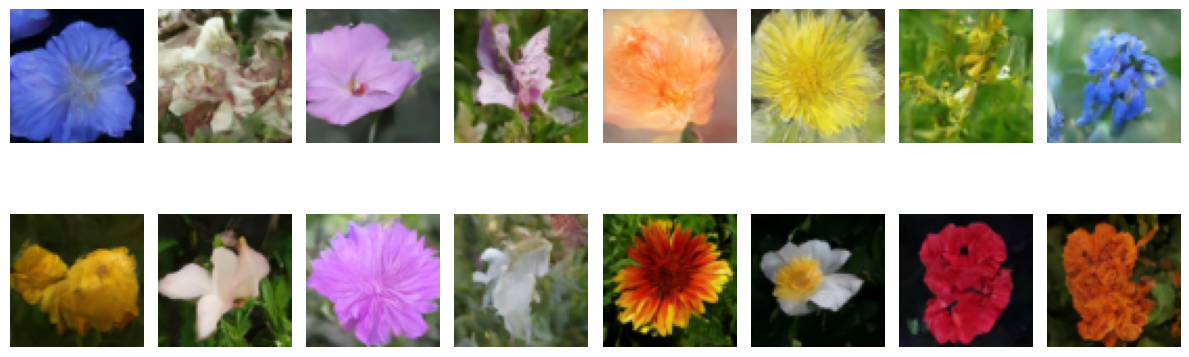

In [17]:
# Generate and plot samples
# To check the results without clipping, set: clip_denoised=False
model.plot_images(num_rows=2, num_cols=8, clip_denoised=True)

### Conclusion

We implemented and trained a DDPM model following the architecture and training procedure described in Section 11.6–11.7. Possible improvements include:

1. Increasing the channel widths for a larger model capacity.
2. Implementing alternative variance schedules such as cosine scheduling.

### References

1. [Denoising Diffusion Probabilistic Models](https://arxiv.org/abs/2006.11239)
2. [Author's implementation](https://github.com/hojonathanho/diffusion)
3. [Keras DDPM example](https://keras.io/examples/generative/ddpm/) (Apache 2.0 License)
4. [Keras DDIM example](https://keras.io/examples/generative/ddim/)
5. [Annotated Diffusion Model](https://huggingface.co/blog/annotated-diffusion)

(c) 2026 S. W. Lee